In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#reading CSV file 
data = pd.read_csv("Housing-selected-columns.csv")
print(data.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  
0              no             yes  
1              no             yes  
2              no              no  
3              no             yes  
4              no             yes  


In [3]:
#chechking for null values
print(data.isnull().sum())
print()
print(data.isnull().sum().sum())

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
dtype: int64

0


In [5]:
data.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   mainroad         545 non-null    object
 6   guestroom        545 non-null    object
 7   basement         545 non-null    object
 8   hotwaterheating  545 non-null    object
 9   airconditioning  545 non-null    object
dtypes: int64(5), object(5)
memory usage: 42.7+ KB


In [7]:
data.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

In [11]:
for col in data.columns:
    if data[col].dtype == 'object':
        print(f"Column: {col}")
        print(data[col].value_counts())
        print()

Column: mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

Column: guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

Column: basement
basement
no     354
yes    191
Name: count, dtype: int64

Column: hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

Column: airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64



In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = label_encoder.fit_transform(data[col])
print(data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  
0         0                0                1  
1         0                0                1  
2         1                0                0  
3         1                0                1  
4         1                0                1  


<Axes: >

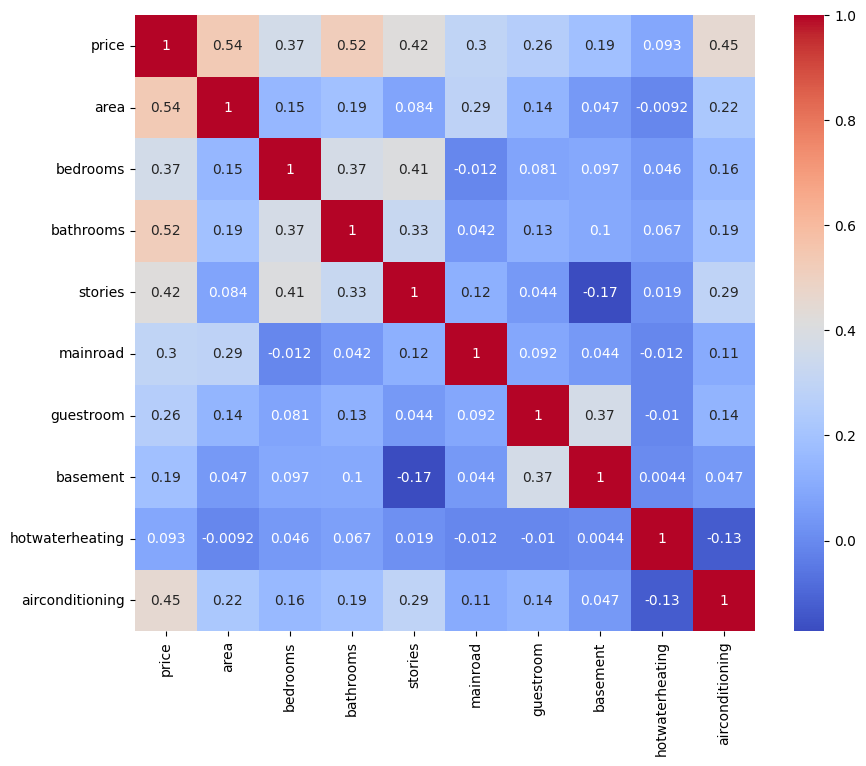

In [14]:
#creating a heatmap to visualize the correlation between features
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

In [30]:
#highest correlation with the target variable 'Price'
correlation_matrix = data.corr()
print(correlation_matrix['price'].sort_values(ascending=False).nlargest(2)) #findng the highest correlation with the target variable 'Price'

price    1.000000
area     0.535997
Name: price, dtype: float64


In [47]:
#importing libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,  mean_absolute_error
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score




In [54]:
# Preparing the data for modeling
X = data.drop('price', axis=1)
y = data['price']

In [55]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
# Building the Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [57]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 1029305.7135858472
Mean Squared Error: 1997147293758.5376
R² Score: 0.6048828690833075


In [58]:
# New house for testing
new_house = [[5000, 3, 2, 2, 1, 0, 1, 0, 1]]

# Predict price
predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 6532967.429432835


c:\Users\Jofin Joseph\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


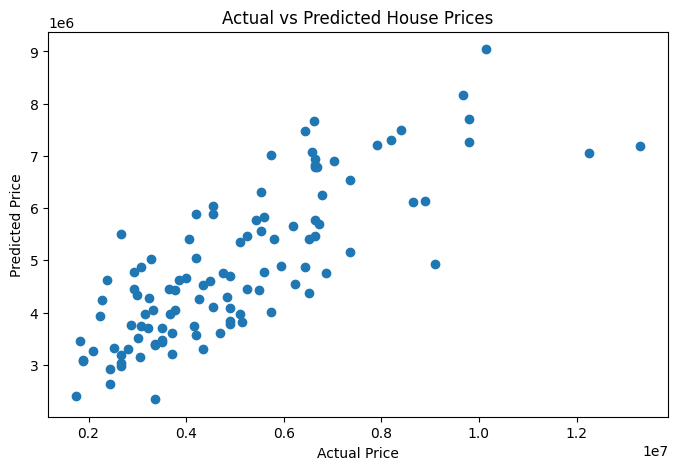

In [ ]:
#plotting actual vs predicted house prices
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

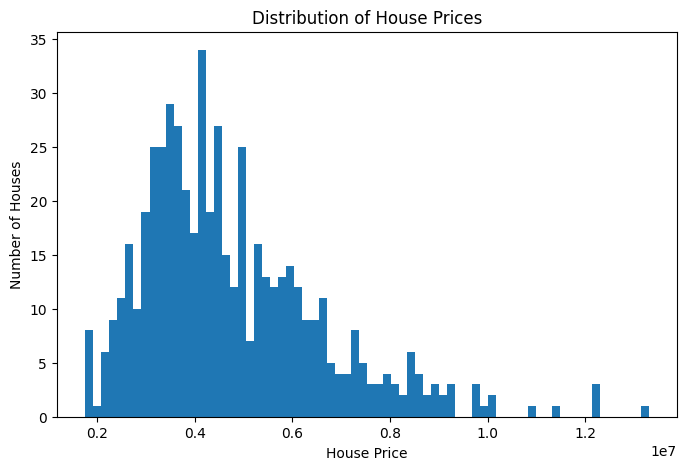

In [ ]:
# Plotting the distribution of house prices
plt.figure(figsize=(8, 5))

plt.hist(data['price'], bins=70)

plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")

plt.show()